In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import mne
import antropy as ant

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import (
    LeaveOneOut, StratifiedKFold, RandomizedSearchCV, 
    cross_val_predict, cross_val_score, KFold
)
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from scipy.stats import pearsonr
from scipy.signal import hilbert

warnings.filterwarnings('ignore')

In [10]:
pasta_features = 'features_extraidas_ec'

# Carregando os dados dos outros notebooks
df_potencia = pd.read_csv(os.path.join(pasta_features, 'features_potencia.csv'))
df_pac = pd.read_csv(os.path.join(pasta_features, 'features_pac.csv'))
df_assimetria = pd.read_csv(os.path.join(pasta_features, 'features_asymmetry.csv'))
df_hjorth = pd.read_csv(os.path.join(pasta_features, 'features_hjorth.csv'))
df_entropia = pd.read_csv(os.path.join(pasta_features, 'features_entropy.csv'))

# Mesclando todos os dataframes usando 'patient_id' e 'pain_score'
# how='inner' para garantir que apenas os pacientes que estão em todas as tabelas sejam mantidos
df_final = df_entropia.merge(df_potencia, on=['patient_id', 'pain_score'], how='inner')
df_final = df_final.merge(df_pac, on=['patient_id', 'pain_score'], how='inner')
df_final = df_final.merge(df_assimetria, on=['patient_id', 'pain_score'], how='inner')
df_final = df_final.merge(df_hjorth, on=['patient_id', 'pain_score'], how='inner')

print(f"Total de pacientes no dataset combinado: {df_final.shape[0]}")
print(f"Total de features combinadas (+ 2 colunas de ID/Target): {df_final.shape[1]}")

# Separando o 'X', 'y' e 'feature_names' para rodar no SVM
y = df_final['pain_score'].values

# Removendo o id e o label para sobrar apenas a matriz de features
df_X = df_final.drop(columns=['patient_id', 'pain_score'])

feature_names = df_X.columns.tolist()
X = df_X.values

print(f"Formato da Matriz X combinada: {X.shape}")

Total de pacientes no dataset combinado: 35
Total de features combinadas (+ 2 colunas de ID/Target): 500
Formato da Matriz X combinada: (35, 498)


In [11]:
csv_filename = 'eeg_ablation_results_ec.csv'

current_condition = 'Eyes Closed'
current_category = 'Todas as Features Combinadas'
classifier_name = 'Linear SVM'

if os.path.exists(csv_filename):
    df_results = pd.read_csv(csv_filename)
    print(f"\nTabela já existe. Registros atuais: {len(df_results)}")
else:
    columns = [
        'Feature_Category', 
        'Classifier', 
        'Condition', 
        'Num_Features', 
        'Accuracy', 
        'AUC_ROC', 
        'F1_Score'
    ]
    df_results = pd.DataFrame(columns=columns)
    print("\nTabela criada com sucesso.")


Tabela já existe. Registros atuais: 31


### Treinamento SVM (LOO) + RFE


Evaluating Linear SVM + RFE — class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 16

Running LOO Nested CV with Linear SVM + RFE...

CLASSIFICATION PERFORMANCE (LOO NESTED CV + LINEAR SVM)
LOO Accuracy: 40.0%
LOO AUC-ROC: 0.322

Best hyperparameters: {'svm_final__C': 0.5}
-------------------------------------------------------

TOP 5 BIOMARKERS (LINEAR SVM + RFE):
  1. PAC_C4_High_Alpha-High_Gamma: 27.3% importance
  2. PAC_T8_Low_Beta-Low_Gamma: 23.8% importance
  3. PAC_P3_Theta-High_Gamma: 18.8% importance
  4. PAC_F7_High_Beta-High_Gamma: 16.2% importance
  5. ApEn_High_Alpha_F3: 13.9% importance


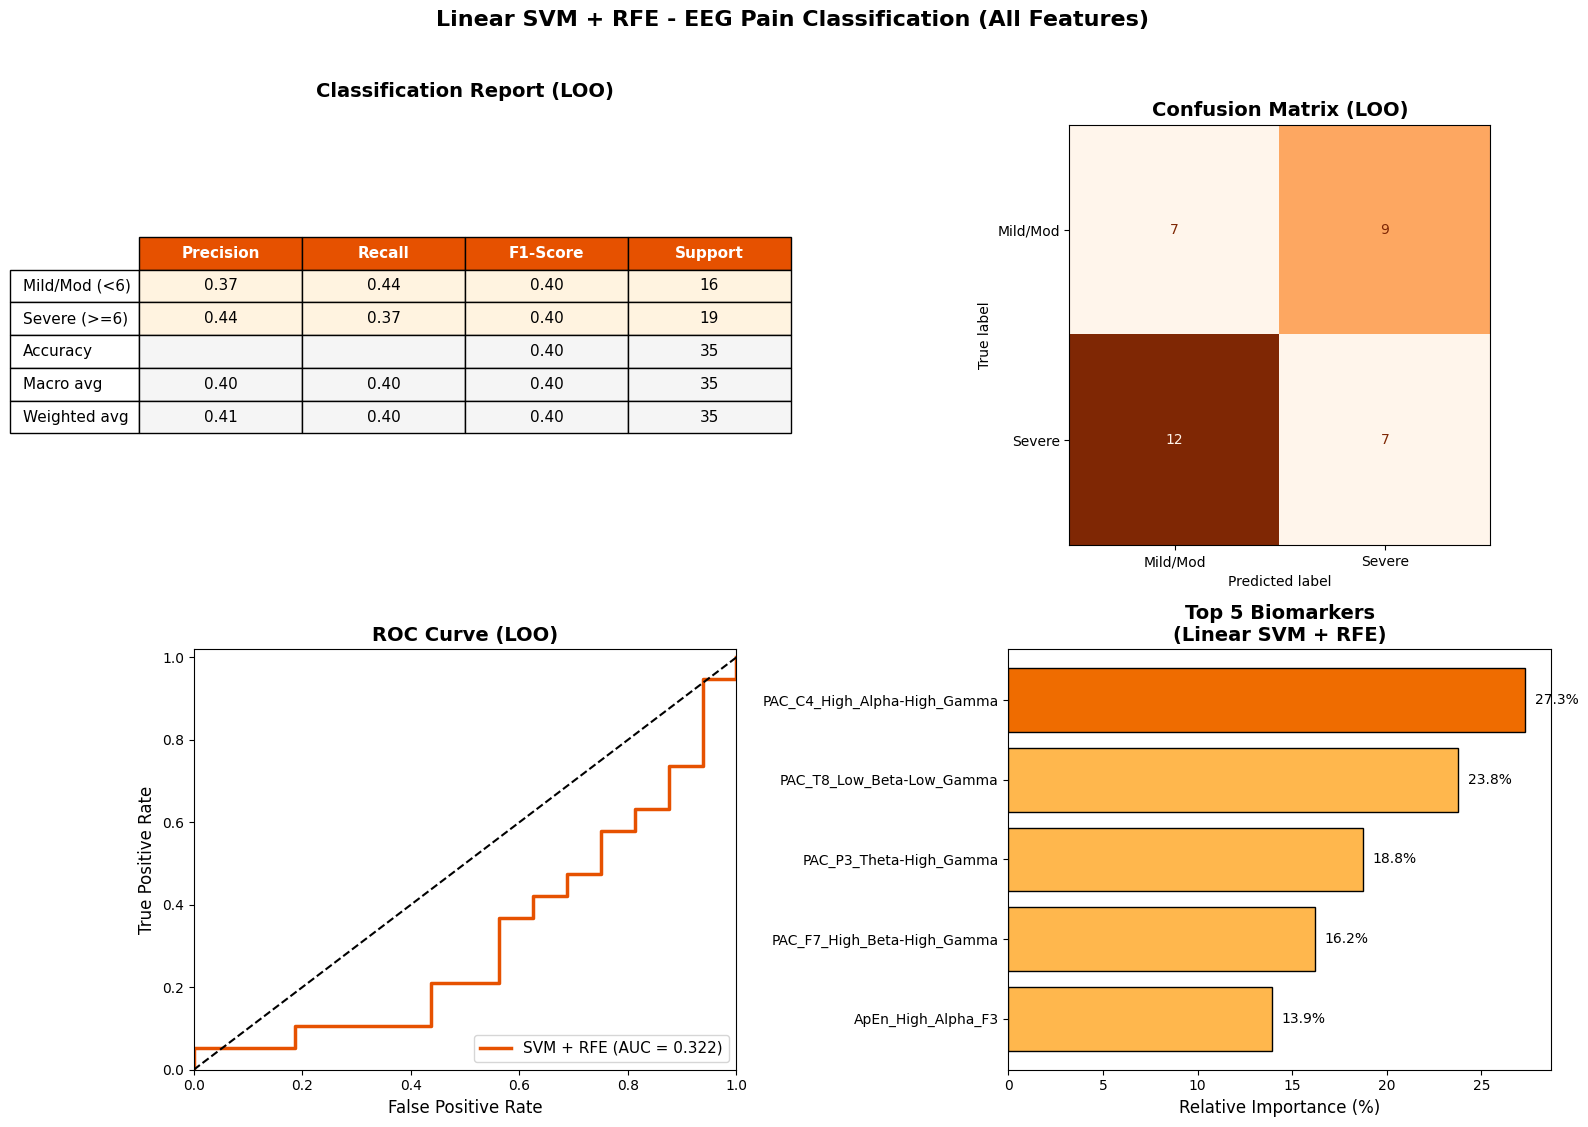


Figure saved as images\svm_linear_rfe_full_results_ec.png
Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [12]:
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print("Evaluating Linear SVM + RFE — class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_k = 5

    # Instanciando o SVM Linear para a seleção de features (RFE)
    svm_rfe = SVC(kernel='linear', random_state=42, class_weight='balanced')
    selector_rfe = RFE(estimator=svm_rfe, n_features_to_select=num_k, step=2)

    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rfe', selector_rfe),
        ('svm_final', SVC(
            kernel='linear',
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Hiperparâmetros
    param_dist = {
        'svm_final__C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=8, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Running LOO Nested CV with Linear SVM + RFE...")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    y_score = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='decision_function')
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_score)
    y_proba = y_score # Para mapeamento no dicionário de resultados
    
    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV + LINEAR SVM)")
    print(f"LOO Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Gerar o dict do classification report
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Treino no dataset completo para extrair a importância dos biomarcadores
    search.fit(X_filtered, y_class)
    print(f"\nBest hyperparameters: {search.best_params_}")
    
    # Extração dos Biomarcadores selecionados pelo RFE
    mask = search.best_estimator_.named_steps['rfe'].get_support()
    biomarkers = feature_names_filt[mask]

    importances = np.abs(search.best_estimator_.named_steps['svm_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k} BIOMARKERS (LINEAR SVM + RFE):")
    for i, idx in enumerate(ranking, 1):
        print(f"  {i}. {biomarkers[idx]}: {importances_pct[idx]:.1f}% importance")

    # (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Tabela do Classification Report
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Matriz de Confusão
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_class, y_score)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5, label=f'SVM + RFE (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    bios_ordered  = biomarkers[ranking]
    scores_ordered = importances_pct[ranking]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Relative Importance (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k} Biomarkers\n(Linear SVM + RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle('Linear SVM + RFE - EEG Pain Classification (All Features)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'svm_linear_rfe_full_results_ec.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

    new_result = pd.DataFrame([{
        'Feature_Category': current_category,
        'Classifier': classifier_name,
        'Condition': current_condition,
        'Num_Features': num_k,
        'Accuracy': round(scores_acc.mean(), 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_score(y_class, y_pred), 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"Resultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")


Avaliando Multi-SVM Hierárquico (Todas as Features Combinadas) - OverSampling + RFE + LOO
Sem Dor (0): 2 pacientes
Leve (1-3): 8 pacientes
Média (4-5): 6 pacientes
Alta (6-7): 11 pacientes
Intolerável (8-10): 8 pacientes


Executando LOO Nested CV...

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 17.1%
LOO AUC-ROC (Weighted): 0.455
-------------------------------------------------------

TOP 5 BIOMARCADORES (Linear SVM RFE):
  1. PAC_O1_Low_Beta-Low_Gamma: 51.2% de importância
  2. Pow_T7_High_Beta: 21.0% de importância
  3. PAC_Cz_Low_Alpha-Low_Gamma: 14.5% de importância
  4. ApEn_Delta_P3: 9.9% de importância
  5. ApEn_Low_Beta_P4: 3.4% de importância


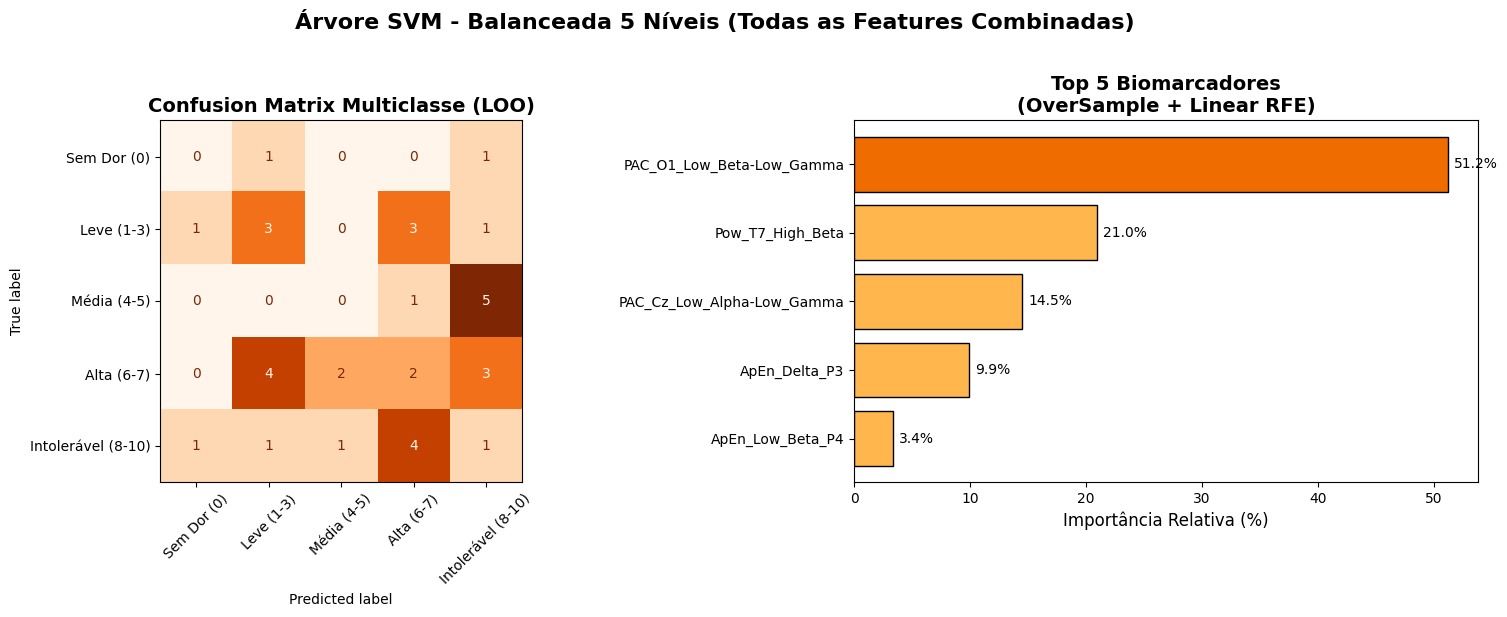


Resultados atualizados no arquivo 'eeg_ablation_results_ec.csv'.


In [13]:
# CLASSE DO MODELO: Árvore de Decisão Hierárquica (Multi-SVM)
class HierarchicalPainSVM(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, gamma='scale'):
        self.C = C
        self.gamma = gamma
        self.node1 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node2 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node3 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)
        self.node4 = SVC(kernel='rbf', C=self.C, gamma=self.gamma, class_weight='balanced', probability=True, random_state=42)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        y = np.array(y)
        
        y1 = np.where(y == 0, 0, 1)
        self.node1.fit(X, y1)
        
        mask2 = (y != 0)
        if np.any(mask2):
            y2 = np.where(y[mask2] == 4, 1, 0)
            self.node2.fit(X[mask2], y2)
            
        mask3 = (y != 0) & (y != 4)
        if np.any(mask3):
            y3 = np.where(y[mask3] == 3, 1, 0)
            self.node3.fit(X[mask3], y3)
            
        mask4 = (y == 1) | (y == 2)
        if np.any(mask4):
            y4 = np.where(y[mask4] == 2, 1, 0)
            self.node4.fit(X[mask4], y4)
            
        return self

    def predict(self, X):
        predictions = []
        for x_i in X:
            x_in = x_i.reshape(1, -1)
            if self.node1.predict(x_in)[0] == 0:
                predictions.append(0)
            elif self.node2.predict(x_in)[0] == 1:
                predictions.append(4)
            elif self.node3.predict(x_in)[0] == 1:
                predictions.append(3)
            elif self.node4.predict(x_in)[0] == 1:
                predictions.append(2)
            else:
                predictions.append(1)
        return np.array(predictions)
        
    def predict_proba(self, X):
        proba = np.zeros((X.shape[0], 5))
        for i, x_i in enumerate(X):
            pred = self.predict(x_i.reshape(1, -1))[0]
            proba[i, pred] = 1.0 
        return proba

# PIPELINE COM OVERSAMPLING + RFE + HIERARCHICAL SVM[cite: 6]
if X.shape[0] > 0:
    print('\n' + '=' * 60)
    print(f"Avaliando Multi-SVM Hierárquico ({current_category}) - OverSampling + RFE + LOO")
    print('=' * 60)

    def map_pain_5_levels(score):
        if score == 0: return 0           
        elif score <= 3: return 1         
        elif score <= 5: return 2         
        elif score <= 7: return 3         
        else: return 4                    

    y_class_hierarchical = np.array([map_pain_5_levels(s) for s in y])
    
    classes_names = ['Sem Dor (0)', 'Leve (1-3)', 'Média (4-5)', 'Alta (6-7)', 'Intolerável (8-10)']
    for i, c_name in enumerate(classes_names):
        print(f"{c_name}: {sum(y_class_hierarchical==i)} pacientes")
    print("\n")

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    num_k = 5 
    
    svm_rfe = SVC(kernel='linear', random_state=42, class_weight='balanced')
    selector_rfe = RFE(estimator=svm_rfe, n_features_to_select=num_k, step=2)

    oversampler = RandomOverSampler(random_state=42)

    base_pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('oversample', oversampler),
        ('rfe', selector_rfe),
        ('hierarchical_svm', HierarchicalPainSVM())
    ])

    param_dist = {
        'hierarchical_svm__C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    }

    inner_cv = KFold(n_splits=3, shuffle=True, random_state=42) 
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=6, cv=inner_cv, scoring='accuracy', 
        random_state=42, n_jobs=-1, refit=True
    )

    print("Executando LOO Nested CV...")
    y_pred = cross_val_predict(search, X_filtered, y_class_hierarchical, cv=outer_cv)
    y_proba = cross_val_predict(search, X_filtered, y_class_hierarchical, cv=outer_cv, method='predict_proba')
    
    acc_loo = np.mean(y_pred == y_class_hierarchical)
    try:
        auc_loo = roc_auc_score(y_class_hierarchical, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_loo = 0.0 
    f1_macro = f1_score(y_class_hierarchical, y_pred, average='macro')

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"LOO AUC-ROC (Weighted): {auc_loo:.3f}")

    search.fit(X_filtered, y_class_hierarchical)
    
    mask = search.best_estimator_.named_steps['rfe'].get_support()
    biomarkers = feature_names_filt[mask]
    coef_originais = search.best_estimator_.named_steps['rfe'].estimator_.coef_[0]
    importances = np.abs(coef_originais)
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k} BIOMARCADORES (Linear SVM RFE):")
    for i, idx in enumerate(ranking, 1):
        print(f"  {i}. {biomarkers[idx]}: {importances_pct[idx]:.1f}% de importância")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_cm, ax_feat = axes[0], axes[1]

    cm = confusion_matrix(y_class_hierarchical, y_pred)
    present_classes = np.unique(np.concatenate([y_class_hierarchical, y_pred]))
    disp_labels = [classes_names[i] for i in present_classes]
    
    disp = ConfusionMatrixDisplay(cm, display_labels=disp_labels)
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges', xticks_rotation=45)
    ax_cm.set_title('Confusion Matrix Multiclasse (LOO)', fontsize=14, fontweight='bold')

    bios_ordered  = biomarkers[ranking]
    scores_ordered = importances_pct[ranking]
    
    colors = ['#ef6c00' if s == scores_ordered.max() else '#ffb74d' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Importância Relativa (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k} Biomarcadores\n(OverSample + Linear RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'Árvore SVM - Balanceada 5 Níveis ({current_category})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, '06_hierarchical_svm_full_results.png') 
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    if os.path.exists(csv_filename):
        df_results = pd.read_csv(csv_filename)
    else:
        df_results = pd.DataFrame()

    new_result = pd.DataFrame([{
        'Feature_Category': current_category + ' + RFE + OverSample',
        'Classifier': "Hierarchical Multi-SVM",
        'Condition': current_condition,
        'Num_Features': num_k,
        'Accuracy': round(acc_loo, 4),
        'AUC_ROC': round(auc_loo, 4),
        'F1_Score': round(f1_macro, 4)
    }])
    
    df_results = pd.concat([df_results, new_result], ignore_index=True)
    df_results.to_csv(csv_filename, index=False)
    print(f"\nResultados atualizados no arquivo '{csv_filename}'.")

else:
    print("Nenhum paciente processado.")

In [14]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

eeg_folder = './cleaned_ec'

Iniciando extração temporal dos Top 5 Biomarcadores do Modelo Combinado...
[PAC_C4_High_Alpha-High_Gamma] Tempo mínimo de estabilidade (>90%): 220 segundos.
[PAC_T8_Low_Beta-Low_Gamma] Tempo mínimo de estabilidade (>90%): 220 segundos.
[PAC_P3_Theta-High_Gamma] Tempo mínimo de estabilidade (>90%): 200 segundos.
[PAC_F7_High_Beta-High_Gamma] Tempo mínimo de estabilidade (>90%): 190 segundos.
[ApEn_High_Alpha_F3] Tempo mínimo de estabilidade (>90%): 170 segundos.


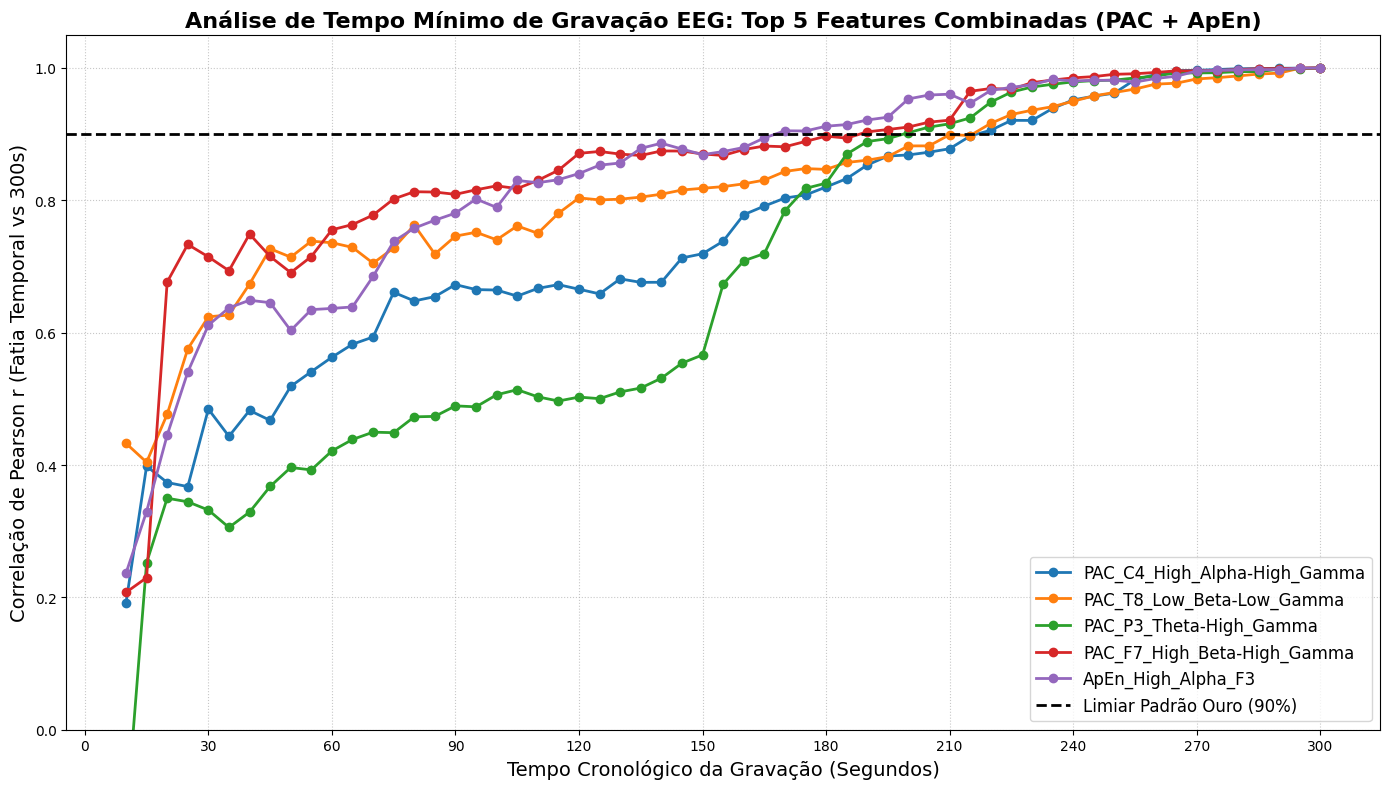

In [15]:
# Top 5 Features do Modelo (Todas as Features)
top_features_combined = [
    {'name': 'PAC_C4_High_Alpha-High_Gamma', 'channel': 'C4', 'feat_type': 'pac', 'phase_band': 'High_Alpha', 'amp_band': 'High_Gamma'},
    {'name': 'PAC_T8_Low_Beta-Low_Gamma',    'channel': 'T8', 'feat_type': 'pac', 'phase_band': 'Low_Beta', 'amp_band': 'Low_Gamma'},
    {'name': 'PAC_P3_Theta-High_Gamma',      'channel': 'P3', 'feat_type': 'pac', 'phase_band': 'Theta', 'amp_band': 'High_Gamma'},
    {'name': 'PAC_F7_High_Beta-High_Gamma',  'channel': 'F7', 'feat_type': 'pac', 'phase_band': 'High_Beta', 'amp_band': 'High_Gamma'},
    {'name': 'ApEn_High_Alpha_F3',           'channel': 'F3', 'feat_type': 'apen', 'band': 'High_Alpha'}
]

bands = {
    'Delta': (0.1, 4), 'Theta': (4, 8), 'Low_Alpha': (8, 10),
    'High_Alpha': (10, 13), 'Low_Beta': (13, 17), 'High_Beta': (18, 30),
    'Low_Gamma': (30, 50), 'High_Gamma': (50, 100)
}

epoch_length_sec = 5
time_steps_sec = np.arange(5, 305, 5)  

def compute_apen(data_epochs_2d):
    """Calcula a Approximate Entropy (ApEn)."""
    apen_vals = []
    for ep_idx in range(data_epochs_2d.shape[0]):
        x = data_epochs_2d[ep_idx, :]
        tol = 0.2 * np.std(x)
        if tol == 0: continue
        ap = ant.app_entropy(x, order=3, metric='chebyshev', tolerance=tol)
        apen_vals.append(ap)
    return np.mean(apen_vals) if len(apen_vals) > 0 else np.nan

def compute_pac_mi(phase_epochs, amp_epochs):
    """Calcula o Modulation Index (PAC) via Transformada de Hilbert de modo autônomo."""
    pac_vals = []
    n_bins = 18
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    
    for ep_idx in range(phase_epochs.shape[0]):
        phase = np.angle(hilbert(phase_epochs[ep_idx, :]))
        amp = np.abs(hilbert(amp_epochs[ep_idx, :]))
        
        bin_phases = np.digitize(phase, bins) - 1
        amp_dist = np.zeros(n_bins)
        
        for b in range(n_bins):
            idx = np.where(bin_phases == b)[0]
            if len(idx) > 0:
                amp_dist[b] = np.mean(amp[idx])
                
        sum_amp = np.sum(amp_dist)
        if sum_amp > 0:
            amp_dist = amp_dist / sum_amp
            h = -np.sum(amp_dist * np.log(amp_dist + 1e-10))
            mi = (np.log(n_bins) - h) / np.log(n_bins)
            pac_vals.append(mi)
            
    return np.mean(pac_vals) if pac_vals else np.nan

def extract_mixed_feature(epochs_slice, feat, sfreq):
    """Roteador para extração baseada na natureza da feature."""
    if feat['channel'] not in epochs_slice.ch_names:
        return np.nan
        
    ch_idx = epochs_slice.ch_names.index(feat['channel'])
    data_2d = epochs_slice.get_data()[:, ch_idx, :]
    
    if feat['feat_type'] == 'apen':
        fmin, fmax = bands[feat['band']]
        filtered_epochs = mne.filter.filter_data(data_2d, sfreq, l_freq=fmin, h_freq=fmax, verbose=False)
        return compute_apen(filtered_epochs)
        
    elif feat['feat_type'] == 'pac':
        p_fmin, p_fmax = bands[feat['phase_band']]
        a_fmin, a_fmax = bands[feat['amp_band']]
        
        phase_data = mne.filter.filter_data(data_2d, sfreq, l_freq=p_fmin, h_freq=p_fmax, verbose=False)
        amp_data = mne.filter.filter_data(data_2d, sfreq, l_freq=a_fmin, h_freq=a_fmax, verbose=False)
        return compute_pac_mi(phase_data, amp_data)

history_combined = {feat['name']: {int(float(pid)): {} for pid in df_complete['ID']} for feat in top_features_combined}

print("Iniciando extração temporal dos Top 5 Biomarcadores do Modelo Combinado...")

# Fatiamento Cronológico e Extração Híbrida
for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID']))
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_ec-epo.fif")
    
    if not os.path.exists(path):
        continue
        
    try:
        epochs = mne.read_epochs(path, preload=True, verbose=False)
        chronological_ids = epochs.events[:, 2] 
        sfreq = epochs.info['sfreq']
        
        # Padrão Ouro (Sinal Total 300s)
        for feat in top_features_combined:
            history_combined[feat['name']][patient_id]['gold'] = extract_mixed_feature(epochs, feat, sfreq)

        # Fatiamento Progressivo
        for t_sec in time_steps_sec:
            max_chronological_id = int(t_sec / epoch_length_sec) - 1
            valid_indices = np.where(chronological_ids <= max_chronological_id)[0]
            epochs_slice = epochs[valid_indices]
            
            if len(epochs_slice) == 0:
                for feat in top_features_combined:
                    history_combined[feat['name']][patient_id][t_sec] = np.nan
            else:
                for feat in top_features_combined:
                    history_combined[feat['name']][patient_id][t_sec] = extract_mixed_feature(epochs_slice, feat, sfreq)
                        
    except Exception as e:
        print(f"Aviso no paciente {patient_id}: {e}")

# Cálculo da Correlação e Gráfico de Convergência (Pearson)
plt.figure(figsize=(14, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
threshold = 0.90

for feat, color in zip(top_features_combined, colors):
    feat_name = feat['name']
    correlations = []
    valid_times = []
    
    valid_patients = [pid for pid, data in history_combined[feat_name].items() if 'gold' in data and not np.isnan(data['gold'])]
    
    for t_sec in time_steps_sec:
        vals_t = []
        vals_gold = []
        
        for pid in valid_patients:
            val_t = history_combined[feat_name][pid].get(t_sec, np.nan)
            val_gold = history_combined[feat_name][pid]['gold']
            
            if not np.isnan(val_t) and not np.isnan(val_gold):
                vals_t.append(val_t)
                vals_gold.append(val_gold)
                
        if len(vals_t) > 10:
            corr, _ = pearsonr(vals_t, vals_gold)
            correlations.append(corr)
            valid_times.append(t_sec)
    
    plt.plot(valid_times, correlations, marker='o', linewidth=2, color=color, label=feat_name)
    
    min_time = next((t for t, c in zip(valid_times, correlations) if c >= threshold), None)
    if min_time:
        print(f"[{feat_name}] Tempo mínimo de estabilidade (>90%): {min_time} segundos.")
    else:
        print(f"[{feat_name}] Não atingiu 90% de estabilidade nos primeiros {max(time_steps_sec)}s.")

plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label='Limiar Padrão Ouro (90%)')

plt.title('Análise de Tempo Mínimo de Gravação EEG: Top 5 Features Combinadas (PAC + ApEn)', fontsize=16, fontweight='bold')
plt.xlabel('Tempo Cronológico da Gravação (Segundos)', fontsize=14)
plt.ylabel('Correlação de Pearson r (Fatia Temporal vs 300s)', fontsize=14)
plt.ylim(0.0, 1.05)
plt.xticks(np.arange(0, 305, 30))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, '06_svm_full_time_convergence.png'), dpi=300)
plt.show()